# Линейный график со стилями 

In [20]:
import pandas as pd
import sqlite3

In [21]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

In [22]:
checker_df = pd.read_sql(
    "SELECT timestamp, uid FROM checker WHERE uid LIKE 'user_%'", 
    conn
)
checker_df['date'] = pd.to_datetime(checker_df['timestamp']).dt.date

views_df = pd.read_sql(
    "SELECT datetime, uid FROM pageviews WHERE uid LIKE 'user_%'", 
    conn
)
views_df['date'] = pd.to_datetime(views_df['datetime']).dt.date

In [23]:
views_df

,datetime,uid,date
0,2020-04-17 22:46:26.785035,user_30,2020-04-17
1,2020-04-18 10:53:52.623447,user_14,2020-04-18
2,2020-04-18 10:56:55.833899,user_17,2020-04-18
3,2020-04-18 10:57:37.331258,user_14,2020-04-18
4,2020-04-18 12:05:48.200144,user_17,2020-04-18
...,...,...,...
982,2020-05-21 18:45:20.441142,user_28,2020-05-21
983,2020-05-21 23:03:06.457819,user_19,2020-05-21
984,2020-05-21 23:23:49.995349,user_25,2020-05-21
985,2020-05-22 11:30:18.368990,user_5,2020-05-22


In [24]:
checker_df

,timestamp,uid,date
0,2020-04-17 05:19:02.744528,user_4,2020-04-17
1,2020-04-17 05:22:35.249331,user_4,2020-04-17
2,2020-04-17 05:22:45.549397,user_4,2020-04-17
3,2020-04-17 05:34:14.691200,user_4,2020-04-17
4,2020-04-17 05:34:24.422370,user_4,2020-04-17
...,...,...,...
3202,2020-05-21 20:19:06.872761,user_1,2020-05-21
3203,2020-05-21 20:22:41.785725,user_1,2020-05-21
3204,2020-05-21 20:22:41.877806,user_1,2020-05-21
3205,2020-05-21 20:37:00.129678,user_1,2020-05-21


In [25]:
commits_per_day = checker_df.groupby('date').size().reset_index(name='commits')
commits_per_day

,date,commits
0,2020-04-17,23
1,2020-04-18,69
2,2020-04-19,33
3,2020-04-20,25
4,2020-04-21,25
5,2020-04-22,28
6,2020-04-23,43
7,2020-04-24,16
8,2020-04-25,104
9,2020-04-26,261


In [26]:
views_per_day = views_df.groupby('date').size().reset_index(name='views')
views_per_day

,date,views
0,2020-04-17,1
1,2020-04-18,23
2,2020-04-19,15
3,2020-04-21,3
4,2020-04-22,1
5,2020-04-23,5
6,2020-04-25,1
7,2020-04-26,8
8,2020-04-28,2
9,2020-04-29,4


In [27]:
result_df = pd.merge(views_per_day, commits_per_day, on='date', how='inner' )
result_df = result_df.sort_values('date').reset_index(drop=True)
result_df

,date,views,commits
0,2020-04-17,1,23
1,2020-04-18,23,69
2,2020-04-19,15,33
3,2020-04-21,3,25
4,2020-04-22,1,28
5,2020-04-23,5,43
6,2020-04-25,1,104
7,2020-04-26,8,261
8,2020-04-28,2,5
9,2020-04-29,4,17


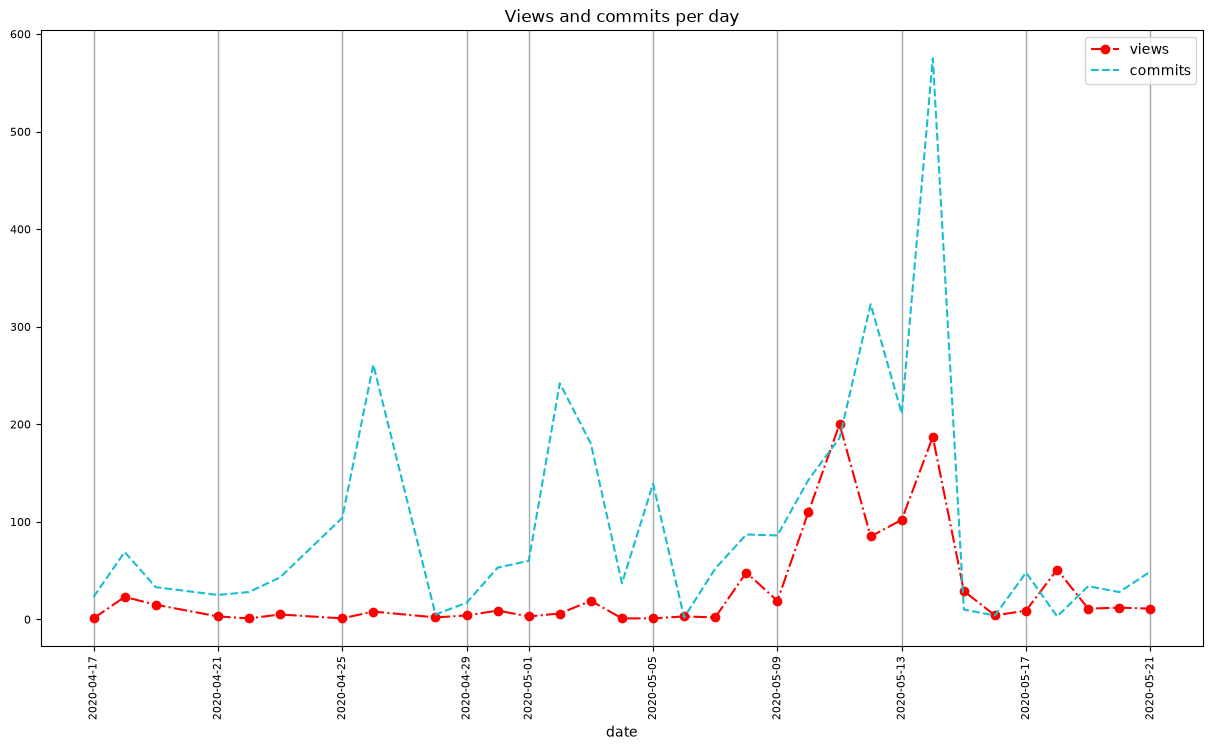

In [28]:


ax = result_df.plot(
    title="Views and commits per day",
    figsize=(15,8),
    x='date',
    rot=90,
    style=['-.o', '--'],        
    color=['red', '#17becf'],
    fontsize=8
)
ax.grid(visible=True, axis='x', color="#9eabac", linestyle='-', linewidth=1)


Сколько раз число просмотров превышало 150?
**Ответ** 2 раза
